In [1]:
import sys
print(sys.executable)


/usr/local/bin/python3


In [2]:
import bz2

train_path = "deeplearning_project copy/archive/train.ft.txt.bz2"

with bz2.open(train_path, mode='rt', encoding='utf-8') as f:
    lines = f.readlines()

for line in lines[:10]:
    print(line)


__label__2 Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^

__label__2 The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny.

__label__2 Amazing!: This soundtrack is

In [3]:
texts = []
labels = []

for line in lines:
    parts = line.strip().split(" ", 1)
    labels.append(1 if parts[0] == "__label__1" else 0)
    texts.append(parts[1])


In [4]:
print(texts[0])
print(labels[0])


Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^
0


In [5]:
print(type(texts))
print(type(labels))


<class 'list'>
<class 'list'>


In [6]:
print(len(texts))
print(texts[0])
print(labels[0])


3600000
Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^
0


In [7]:
import pandas as pd

df = pd.DataFrame({
    "text": texts,
    "label": labels
})

df.head()


,text,label
0,Stuning even for the non-gamer: This sound tra...,0
1,The best soundtrack ever to anything.: I'm rea...,0
2,Amazing!: This soundtrack is my favorite music...,0
3,Excellent Soundtrack: I truly like this soundt...,0
4,"Remember, Pull Your Jaw Off The Floor After He...",0


In [8]:
import os
print(os.listdir())


['.DS_Store', 'sentiment_model.joblib', '__pycache__', 'tokenizer.pkl', 'sentiment_model.pkl', 'deeplearning_project copy', 'vectorizer.pkl', 'deeplearning_project.ipynb', 'sentiment.html', 'csv.ipynb', 'try.html']


In [9]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
df["clean_text"] = df["text"].apply(clean_text)


In [10]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [11]:
print(df)

                                                      text  label  \
0        Stuning even for the non-gamer: This sound tra...      0   
1        The best soundtrack ever to anything.: I'm rea...      0   
2        Amazing!: This soundtrack is my favorite music...      0   
3        Excellent Soundtrack: I truly like this soundt...      0   
4        Remember, Pull Your Jaw Off The Floor After He...      0   
...                                                    ...    ...   
3599995  Don't do it!!: The high chair looks great when...      1   
3599996  Looks nice, low functionality: I have used thi...      1   
3599997  compact, but hard to clean: We have a small ho...      1   
3599998  what is it saying?: not sure what this book is...      1   
3599999  Makes My Blood Run Red-White-And-Blue: I agree...      0   

                                                clean_text  
0        stuning even for the nongamer this sound track...  
1        the best soundtrack ever to anything im 

In [12]:
import sys
!{sys.executable} -m pip install scikit-learn


  Using cached scikit_learn-1.7.2-cp310-cp310-macosx_12_0_arm64.whl (8.7 MB)
     |████████████████████████████████| 22.4 MB 2.4 MB/s eta 0:00:01
You should consider upgrading via the '/usr/local/bin/python3 -m pip install --upgrade pip' command.


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = df["clean_text"]
y = df["label"]


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [16]:

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

In [17]:
df = df.sample(n=100_000, random_state=42)


In [18]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [19]:
split = int(0.8 * len(df))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=3000,     # fast + sufficient
    ngram_range=(1, 1)     # only unigrams
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)


In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=500,
    solver="liblinear"
)

model.fit(X_train_vec, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,500
,multi_class,'deprecated'


In [23]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.884
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     10005
           1       0.88      0.89      0.88      9995

    accuracy                           0.88     20000
   macro avg       0.88      0.88      0.88     20000
weighted avg       0.88      0.88      0.88     20000



In [24]:
import re

def clean_text_local(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def predict_sentiment(text):
    text = clean_text_local(text)
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec).max()

    sentiment = "Positive" if pred == 1 else "Negative"
    return sentiment, round(prob * 100, 2)


In [25]:
df["label"].value_counts()


label
1    50013
0    49987
Name: count, dtype: int64

In [26]:
test_text = "this product is amazing"

vec = vectorizer.transform([test_text])
print(model.predict(vec))
print(model.predict_proba(vec))


[0]
[[0.98915328 0.01084672]]


In [27]:
print(df["label"].value_counts())


label
1    50013
0    49987
Name: count, dtype: int64


In [28]:
df.groupby("label").head(3)


,text,label,clean_text
2079998,Expensive Junk: This product consists of a pie...,1,expensive junk this product consists of a piec...
1443106,"Toast too dark: Even on the lowest setting, th...",1,toast too dark even on the lowest setting the ...
3463669,Excellent imagery...dumbed down story: I enjoy...,0,excellent imagerydumbed down story i enjoyed t...
2914699,Are we pretending everyone is married?: The au...,1,are we pretending everyone is married the auth...
431645,This import is sooooooooooo good: This is a gr...,0,this import is sooooooooooo good this is a gre...
36844,"Amazing, Fascinating: This was a stunning book...",0,amazing fascinating this was a stunning book w...


In [29]:
def predict_sentiment_fixed(text):
    text = clean_text_local(text)
    vec = vectorizer.transform([text])
    probs = model.predict_proba(vec)[0]

    print("Raw probabilities:", probs)

    if probs[0] > probs[1]:
        return "Positive", float(round(probs[0] * 100, 2))
    else:
        return "Negative", float(round(probs[1] * 100, 2))


In [30]:
print(predict_sentiment_fixed("this product is bad"))
print(predict_sentiment_fixed("mera dost bhout acha hai"))



Raw probabilities: [0.03466171 0.96533829]
('Negative', 96.53)
Raw probabilities: [0.50766434 0.49233566]
('Positive', 50.77)


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)


In [32]:
X_test_vec = vectorizer.transform(X_test)
y_pred = model.predict(X_test_vec)


In [33]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc * 100)


Test Accuracy: 88.65902777777778


In [34]:
import joblib
joblib.dump(model, "sentiment_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")


['vectorizer.pkl']

In [35]:
joblib.dump(model, "deeplearning_project copy/sentiment_model.pkl")
joblib.dump(vectorizer, "deeplearning_project copy/sentiment_vectorizer.pkl")


['deeplearning_project copy/sentiment_vectorizer.pkl']

In [36]:
import joblib

model = joblib.load("deeplearning_project copy/sentiment_model.pkl")
vectorizer = joblib.load("deeplearning_project copy/sentiment_vectorizer.pkl")


In [37]:
feedback_texts = ["I  love working here", "Workload is too high"]
X_vec = vectorizer.transform(feedback_texts)
y_pred = model.predict(X_vec)
probs = model.predict_proba(X_vec)

for text, pred, prob in zip(feedback_texts, y_pred, probs.max(axis=1)):
    sentiment = "Positive" if pred == 0 else "Negative"
    print(text, "->", sentiment, round(prob*100, 2), "%")


I  love working here -> Positive 91.19 %
Workload is too high -> Negative 86.8 %


In [38]:
import re

def fix_misspellings(text):
    text = re.sub(r'\btuf\b', 'tough', text)
    return text

text = fix_misspellings("programing is tuf")


In [39]:
print(text)

programing is tough


In [40]:
print(model.classes_)


[0 1]


In [41]:
feedback_texts = [
    "I was pleasantly surprised at the changes in the book.",
    "don't the world was raving about this book and so I bought it. there was very bad"
]

def normalize(t):
    return t.lower().replace("don't","do not").replace("can't","can not").replace("won't","will not")

POS = {"like","love","good","great","amazing","best","raving"}
NEG = {"not","bad","hate","worst","boring","dislike"}

texts = [normalize(t) for t in feedback_texts]

X = vectorizer.transform(texts)
pred = model.predict(X)
probs = model.predict_proba(X)

label = {model.classes_[0]:"Positive", model.classes_[1]:"Negative"}

for t, p, pr in zip(texts, pred, probs):
    if any(w in t for w in POS) and any(w in t for w in NEG):
        print(t, "-> Neutral 100 %")
    else:
        print(t, "->", label[p], round(max(pr)*100,2), "%")


i was pleasantly surprised at the changes in the book. -> Positive 95.49 %
do not the world was raving about this book and so i bought it. there was very bad -> Neutral 100 %


In [42]:
import sys
!{sys.executable} -m pip install vaderSentiment


You should consider upgrading via the '/usr/local/bin/python3 -m pip install --upgrade pip' command.


In [43]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    c = analyzer.polarity_scores(text)['compound']

    if c >= 0.3:
        s = "Positive"
    elif c <= -0.3:
        s = "Negative"
    else:
        s = "Neutral"

    return s, round(abs(c)*100, 2)


In [44]:
print(analyzer.polarity_scores(
    "I am not normaly someone who is into romance novels"
))


{'neg': 0.0, 'neu': 0.714, 'pos': 0.286, 'compound': 0.5574}


data se test

In [45]:
#print(get_sentiment("I am not normaly someone who is into romance novels"))
# if tume data set se word leke test krna hai to yah pr kro

#print(get_sentiment("but the world was raving about this book and so I bought it."))
print(get_sentiment("riya worked very nice"))
print(get_sentiment("but army work is very hard"))

('Positive', 47.54)
('Neutral', 25.92)


In [46]:
def predict_5_class_sentiment(text):
    text = text.lower()
    very_positive_words = ["excellent", "awesome", "amazing", "outstanding", "fantastic"]
    positive_words = ["good", "nice", "like", "love", "happy"]
    negative_words = ["bad", "poor", "dislike", "sad", "problem","bhought"]
    very_negative_words = ["worst", "terrible", "horrible", "awful", "hate"]
    score = 0
    for word in very_positive_words:
        if word in text:
            score += 2
    for word in positive_words:
        if word in text:
            score += 1
    for word in negative_words:
        if word in text:
            score -= 1
    for word in very_negative_words:
        if word in text:
            score -= 2
    if score >= 2:
        return "Very Positive"
    elif score == 1:
        return "Positive"
    elif score == 0:
        return "Neutral"
    elif score == -1:
        return "Negative"
    else:
        return "Very Negative"
if __name__ == "__main__":
    print("5-Class Sentiment Analysis")
    print("Type 'exit' to quit.\n")

    while True:
        text = input("Enter your sentence: ")

        if text.lower() == "exit":
            break

        result = predict_5_class_sentiment(text)
        print("Predicted Sentiment:", result)
        print("-" * 40)


5-Class Sentiment Analysis
Type 'exit' to quit.

Predicted Sentiment: Neutral
----------------------------------------


impliment bert


In [47]:
import importlib.util, sys
if importlib.util.find_spec("transformers") is None:
    print("Installing transformers...")
    !{sys.executable} -m pip install -q transformers



In [48]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch


model_name = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2203.11it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense

In [49]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    tokenizer="distilbert-base-uncased-finetuned-sst-2-english"
)

result = classifier("Stock market is performing very good today")
print(result)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2172.27it/s, Materializing param=pre_classifier.weight]                                  


[{'label': 'POSITIVE', 'score': 0.9998015761375427}]


In [50]:
# final_bert_sentiment.py

from transformers import pipeline
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    tokenizer="distilbert-base-uncased-finetuned-sst-2-english"
)

def predict_sentiment(text):
    result = classifier(text)[0]  
    label = result['label']
    score = result['score']

    if score < 0.6:
        label = "NEUTRAL"

    return label, score

print("BERT Sentiment Analysis (type 'exit' to quit)")
while True:
    text = input("Enter text: ")
    if text.lower() == "exit":
        break

    sentiment, confidence = predict_sentiment(text)
    print(f"Input: {text}")
    print(f"Sentiment: {sentiment}, Confidence: {confidence:.2f}")
    print("-" * 40)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1825.50it/s, Materializing param=pre_classifier.weight]                                  


BERT Sentiment Analysis (type 'exit' to quit)


In [51]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

In [52]:
import torch.nn.functional as F

In [53]:
model_name = "cardiffnlp/twitter-roberta-base-sentiment"

In [54]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2834.07it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [55]:
labels = ["Negative", "Neutral", "Positive"]

In [56]:
def predict_sentiment(text):
    
    inputs = tokenizer(text, return_tensors="pt", truncation=True)
    
    outputs = model(**inputs)

    
    probs = F.softmax(outputs.logits, dim=1)

    predicted_class = torch.argmax(probs).item()

    return labels[predicted_class], probs[0][predicted_class].item()

In [57]:
texts = [
    "he is my best friend",
    "The meeting is scheduled for 3 PM tomorrow.",
    "but army work is very hard."
]

for text in texts:
    sentiment, score = predict_sentiment(text)
    print(f"Text: {text}")
    print(f"Sentiment: {sentiment} (Confidence: {score:.2f})")
    print("-" * 50)

Text: he is my best friend
Sentiment: Positive (Confidence: 0.97)
--------------------------------------------------
Text: The meeting is scheduled for 3 PM tomorrow.
Sentiment: Neutral (Confidence: 0.93)
--------------------------------------------------
Text: but army work is very hard.
Sentiment: Negative (Confidence: 0.75)
--------------------------------------------------


In [58]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import torch.nn.functional as F

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("nlptown/bert-base-multilingual-uncased-sentiment")

def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    logits = outputs.logits
    probs = F.softmax(logits, dim=1)
    score, predicted_class = torch.max(probs, dim=1)
    return predicted_class.item(), score.item()

texts = [
    "he is my best friend",
    "The meeting is scheduled for 3 PM tomorrow.",
    "but army work is very hard."
]

for text in texts:
    sentiment, score = predict_sentiment(text)
    print("Text:", text)
    print("Sentiment:", sentiment)
    print("Confidence:", round(score,2))
    print("-"*50)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1817.60it/s, Materializing param=classifier.weight]                                      


Text: he is my best friend
Sentiment: 4
Confidence: 0.41
--------------------------------------------------
Text: The meeting is scheduled for 3 PM tomorrow.
Sentiment: 2
Confidence: 0.35
--------------------------------------------------
Text: but army work is very hard.
Sentiment: 0
Confidence: 0.39
--------------------------------------------------


FINAL DIFFRANCE LSTM AND BERT


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# hmne bnaya hai
data = {
    "text": [
        "I love this product",
        "This is the worst thing",
        "Amazing experience",
        "I hate it",
        "Very good",
        "Not bad",
        "Terrible service",
        "Best purchase ever"
    ],
    "label": [1, 0, 1, 0, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

In [61]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [62]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['text'])
sequences = tokenizer.texts_to_sequences(df['text'])

X = pad_sequences(sequences)
y = np.array(df['label'])

# Model
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=1000, output_dim=64))
model_lstm.add(LSTM(64))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model_lstm.fit(X, y, epochs=5, verbose=1)

lstm_acc = history.history['accuracy'][-1]
print("LSTM Accuracy:", lstm_acc)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 826ms/step - accuracy: 0.6250 - loss: 0.6911
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7500 - loss: 0.6864
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7500 - loss: 0.6816
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7500 - loss: 0.6767
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6250 - loss: 0.6715
LSTM Accuracy: 0.625


In [63]:
from transformers import pipeline


In [64]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2153.53it/s, Materializing param=pre_classifier.weight]                                  


In [65]:
correct = 0
predictions = []

for i in range(len(df)):
    result = classifier(df['text'][i])[0]
    
    pred = 1 if result['label'] == 'POSITIVE' else 0
    predictions.append(pred)
    
    if pred == df['label'][i]:
        correct += 1

bert_acc = correct / len(df)

print("BERT Accuracy:", bert_acc)

BERT Accuracy: 1.0


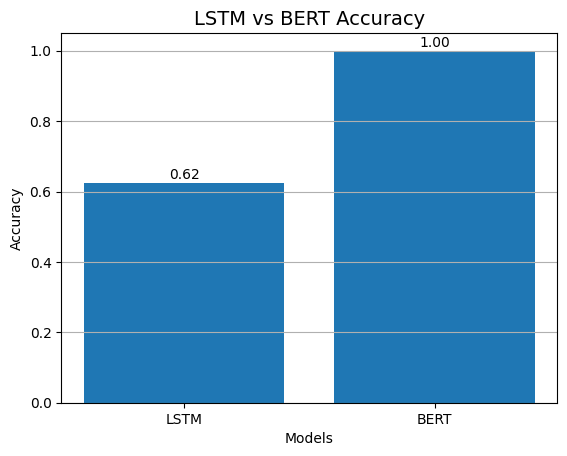

In [73]:
import matplotlib.pyplot as plt

models = ["LSTM", "BERT"]
accuracy = [0.625, 1.0]

plt.figure()

bars = plt.bar(models, accuracy)

plt.title("LSTM vs BERT Accuracy", fontsize=14)
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i in range(len(models)):
    plt.text(i, accuracy[i] + 0.01, f"{accuracy[i]:.2f}", ha='center')

plt.grid(axis='y')

plt.show()